## Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

#Task 1: Data Understanding and Visualization:

##1.1 Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

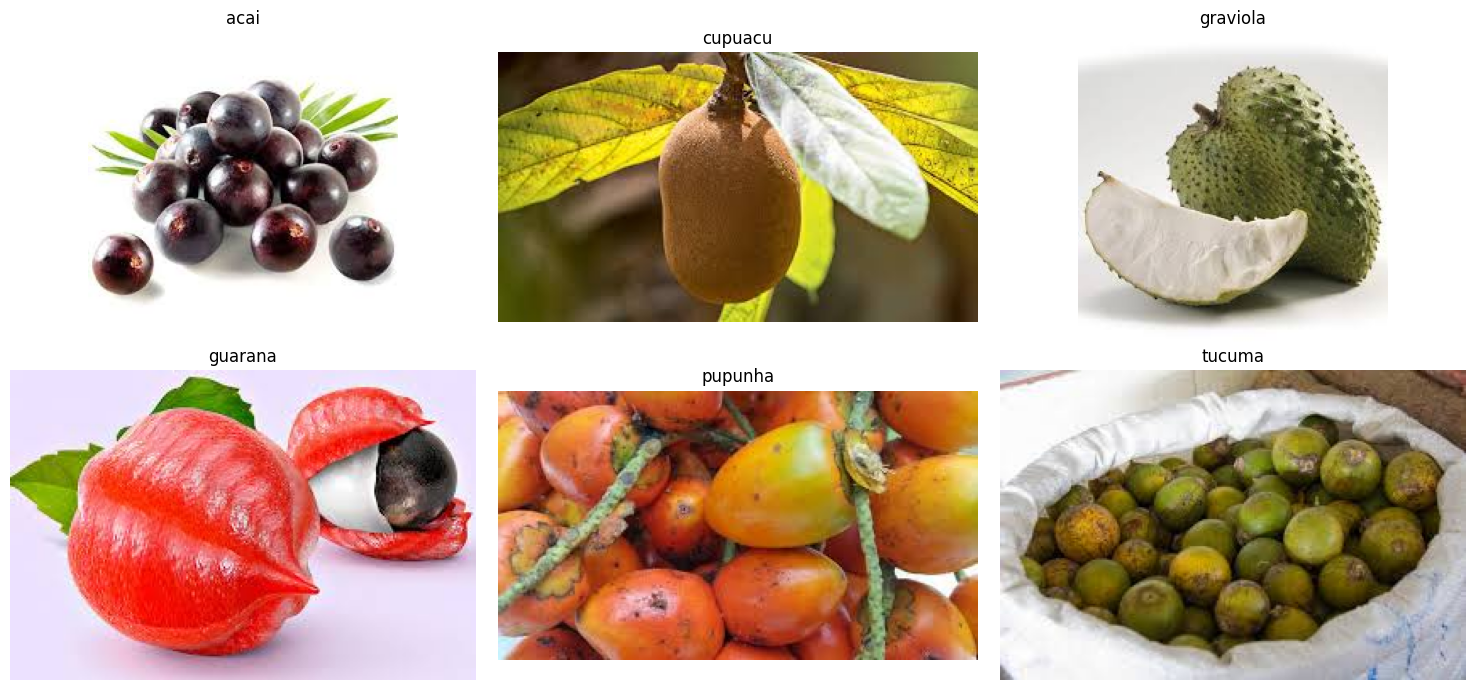

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

#load dataset
train_dir = "/content/drive/MyDrive/AI and ML/Workshop and worksheets/Week 5/FruitinAmazon/train"

# Get the list of class directories
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Setup the figure for a grid with two rows
cols = (num_classes + 1) // 2
plt.figure(figsize=(15, 7))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    # Get all images in the class directory
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Select one image randomly
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    # Load and display
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
corrupted_images = []
# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Attempt to open and verify the image
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                # If corrupted, remove and log
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
  print("No Corrupted Images Found.")
else:
  print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [4]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with

In [5]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Task 4: Compile the Model

In [6]:
# Task 4: Compilation and Training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_fruit_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.1655 - loss: 1.8875

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 962ms/step - accuracy: 0.1528 - loss: 1.9371 - val_accuracy: 0.0556 - val_loss: 1.7877
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.3287 - loss: 1.6317

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 645ms/step - accuracy: 0.3611 - loss: 1.6332 - val_accuracy: 0.7222 - val_loss: 1.4207
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.5278 - loss: 1.3858 - val_accuracy: 0.2222 - val_loss: 1.6762
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5492 - loss: 1.1761

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.5694 - loss: 1.1221 - val_accuracy: 0.6111 - val_loss: 0.8354
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 430ms/step - accuracy: 0.5556 - loss: 0.9980 - val_accuracy: 0.7222 - val_loss: 0.8433
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.8194 - loss: 0.6628 - val_accuracy: 0.6667 - val_loss: 1.1288
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7876 - loss: 0.5494

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.8472 - loss: 0.5105 - val_accuracy: 0.8333 - val_loss: 0.5633
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 737ms/step - accuracy: 0.9444 - loss: 0.3538 - val_accuracy: 0.7778 - val_loss: 0.6422
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 517ms/step - accuracy: 1.0000 - loss: 0.1525 - val_accuracy: 0.8333 - val_loss: 0.6813
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 1.0000 - loss: 0.1570

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 1.0000 - loss: 0.1353 - val_accuracy: 0.8333 - val_loss: 0.4020
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9803 - loss: 0.0619

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.9722 - loss: 0.0662 - val_accuracy: 0.8889 - val_loss: 0.3147
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 1.0000 - loss: 0.0352 - val_accuracy: 0.8333 - val_loss: 0.5429
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - accuracy: 1.0000 - loss: 0.0306 - val_accuracy: 0.8333 - val_loss: 0.6737
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 1.0000 - loss: 0.0182 - val_accuracy: 0.8333 - val_loss: 0.5579
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 730ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.8889 - val_loss: 0.3827
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.8889 - val_loss: 0.4293
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.8889 - val_loss: 0.4170
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 405ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8333 - val_lo

#Task 5 -Evaluate the model


In [7]:
# Task 5: Evaluation
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8889 - loss: 0.3147
Validation Accuracy: 0.8889


#Task 6: Save and Load the Model

In [8]:
import numpy as np
from sklearn.metrics import classification_report

# Task 6: Save and Load
model.save('final_model.h5')
new_model = tf.keras.models.load_model('final_model.h5')

# Task 7: Predictions and Report

In [9]:
# Task 7: Predictions and Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = new_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       1.00      0.93      0.97        15

    accuracy                           0.89        18
   macro avg       0.50      0.40      0.44        18
weighted avg       1.00      0.89      0.94        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Workshop 7 continued from here

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    # Select the first image from the batch
    first_image = images[0]

    for i in range(9):
        # 2. Apply augmentation to the same image
        # We add a dimension using [tf.newaxis] because the layer expects a batch
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        # 3. Plot the result
        ax = plt.subplot(3, 3, i + 1)
        # Convert to uint8 for display (undoing normalization if necessary)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Augmentation {i+1}")
        plt.axis("off")

plt.suptitle("Visualizing Random Augmentations on a Single Image")
plt.show()

NameError: name 'data_augmentation' is not defined

<Figure size 1000x1000 with 0 Axes>